✅ Qué sabemos del dataset WASABI

El dataset cubre más de 2 millones de canciones comerciales, ~200 000 álbumes y ~77 000 artistas.


Contiene metadatos extraídos de diversas bases de datos musicales, letras de canciones procesadas y análisis de audio.


Incluye anotaciones relacionadas con estructura de la letra (segmentación), temas, explícito del contenido lírico, pasajes destacados de canciones y emociones.


Está disponible tanto en formato JSON como en formato RDF (Knowledge Graph) para consulta semántica

In [3]:
# 🔧 Nueva lectura del CSV Wasabi correctamente delimitado por tabulaciones

from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("WasabiFix").getOrCreate()

input_path = "/content/drive/MyDrive/proyectoInvestigativo/wasabi_songs.csv"  # ajusta la ruta

# Leer con delimitador explícito "\t"
df = (spark.read
      .option("header", True)
      .option("delimiter", "\t")
      .option("multiLine", True)
      .option("quote", "\"")
      .csv(input_path)
)

print("✅ Estructura corregida:")
df.printSchema()
print("\nPrimeras filas:")
df.show(5, truncate=120)

print("\nTotal de filas:", df.count())


✅ Estructura corregida:
root
 |-- _c0: string (nullable = true)
 |-- _id: string (nullable = true)
 |-- abstract: string (nullable = true)
 |-- albumTitle: string (nullable = true)
 |-- album_genre: string (nullable = true)
 |-- animux_content: string (nullable = true)
 |-- animux_contents: string (nullable = true)
 |-- animux_path: string (nullable = true)
 |-- animux_paths: string (nullable = true)
 |-- arousal: string (nullable = true)
 |-- arousal_predicted: string (nullable = true)
 |-- artist: string (nullable = true)
 |-- artist_lower: string (nullable = true)
 |-- availableCountries: string (nullable = true)
 |-- award: string (nullable = true)
 |-- begin: string (nullable = true)
 |-- bpm: string (nullable = true)
 |-- chords_metadata: string (nullable = true)
 |-- deezer_mapping: string (nullable = true)
 |-- disambiguation: string (nullable = true)
 |-- end: string (nullable = true)
 |-- explicit_content_lyrics: string (nullable = true)
 |-- explicit_content_lyrics_predicted

| **Variable**                                                            | **Descripción**                                                                   | **Tipo / Ejemplo**                              |
| ----------------------------------------------------------------------- | --------------------------------------------------------------------------------- | ----------------------------------------------- |
| `_id`                                                                   | Identificador único de cada canción dentro del dataset.                           | `"ObjectId(5714dec325ac0d8aee3804e7)"`          |
| `abstract`                                                              | Descripción corta o sinopsis del contenido de la canción o álbum.                 | `"An energetic rock song about..."`             |
| `albumTitle`                                                            | Nombre del álbum al que pertenece la canción.                                     | `"How Ace Are Buildings"`                       |
| `album_genre`                                                           | Género principal del álbum.                                                       | `"Alternative Rock"`                            |
| `artist`                                                                | Nombre del artista o banda principal.                                             | `"A"`                                           |
| `availableCountries`                                                    | Lista de países donde está disponible la canción.                                 | `"['US', 'UK', 'CA', ...]"`                     |
| `award`                                                                 | Información sobre premios recibidos por la canción o el álbum (si aplica).        | `"Grammy Award for Best Song"`                  |
| `bpm`                                                                   | Velocidad de la canción en beats por minuto.                                      | `120`                                           |
| `chords_metadata`                                                       | Información estructurada de acordes y progresiones extraída de análisis armónico. | JSON con tiempos, acordes, duración, confianza. |
| `deezer_mapping`                                                        | Identificadores asociados a la plataforma Deezer.                                 | `"[ [67354194, 'search-exact'] ]"`              |
| `explicit_content_lyrics`                                               | Indica si la canción tiene contenido explícito según metadatos.                   | `"True"` o `"False"`                            |
| `format`                                                                | Formato del audio o tipo de publicación.                                          | `"MP3"`, `"FLAC"`                               |
| `genre`                                                                 | Género musical de la canción.                                                     | `"Pop"`, `"Rock"`, `"Jazz"`                     |
| `has_emotion_tags`                                                      | Indica si existen etiquetas emocionales asociadas.                                | `"True"` o `"False"`                            |
| `id_album`, `id_artist_deezer`, `id_song_deezer`, `id_song_musicbrainz` | Identificadores cruzados con plataformas musicales.                               | `"3db608e4-eb72..."`                            |
| `isClassic`                                                             | Bandera que marca si la canción pertenece a un repertorio clásico.                | `"True"` o `"False"`                            |
| `isrc`                                                                  | Código internacional estándar de grabación (identificador global de pista).       | `"GBAAP9700050"`                                |
| `language` / `language_detect`                                          | Idioma principal detectado de la canción.                                         | `"english"`, `"spanish"`                        |
| `length`                                                                | Duración de la canción en segundos.                                               | `184.0`                                         |
| `publicationDate` / `releaseDate`                                       | Fecha de publicación y lanzamiento.                                               | `"1998-06-22"`                                  |
| `recordLabel`                                                           | Compañía discográfica.                                                            | `"Sony Music"`, `"EMI"`                         |
| `runtime`                                                               | Duración en formato de tiempo (hh:mm:ss).                                         | `"00:03:24"`                                    |
| `title`                                                                 | Título de la canción.                                                             | `"Turn It Up"`                                  |
| `valence`                                                               | Valor de positividad emocional o felicidad de la canción (0–1).                   | `0.65`                                          |
| `arousal`                                                               | Nivel de excitación o energía percibida (0–1).                                    | `0.47`                                          |
| `producer`, `writer`                                                    | Productores y escritores de la canción.                                           | `"Rick Rubin"`, `"Paul McCartney"`              |
| `urlAllmusic`, `urlSpotify`, `urlYouTube`, `urlWikipedia`, etc.         | Enlaces a diferentes plataformas y fuentes de información.                        | URLs varias.                                    |


Schema inicial:
root
 |-- _c0: string (nullable = true)
 |-- _id: string (nullable = true)
 |-- abstract: string (nullable = true)
 |-- albumTitle: string (nullable = true)
 |-- album_genre: string (nullable = true)
 |-- animux_content: string (nullable = true)
 |-- animux_contents: string (nullable = true)
 |-- animux_path: string (nullable = true)
 |-- animux_paths: string (nullable = true)
 |-- arousal: string (nullable = true)
 |-- arousal_predicted: string (nullable = true)
 |-- artist: string (nullable = true)
 |-- artist_lower: string (nullable = true)
 |-- availableCountries: string (nullable = true)
 |-- award: string (nullable = true)
 |-- begin: string (nullable = true)
 |-- bpm: string (nullable = true)
 |-- chords_metadata: string (nullable = true)
 |-- deezer_mapping: string (nullable = true)
 |-- disambiguation: string (nullable = true)
 |-- end: string (nullable = true)
 |-- explicit_content_lyrics: string (nullable = true)
 |-- explicit_content_lyrics_predicted: string

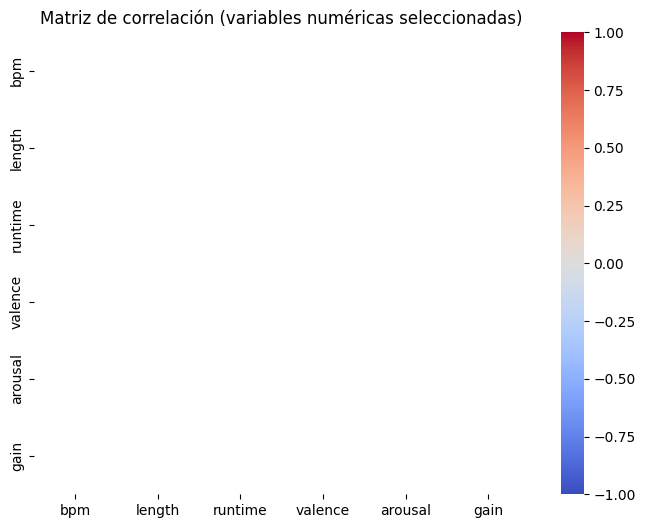

Correlaciones clave (> |0.5|):
Tamaños resultantes:
  Entrenamiento: 253920
  Prueba: 254713
  Validación: 2031695
📦 ZIP generado en: /content/drive/MyDrive/proyectoInvestigativo/wasabi_full_parquet_nofilters.zip (~668.08 MB)

✔️ Proceso completado sin filtros de outliers. Queda listo para análisis posterior.


In [5]:




from pyspark.sql import SparkSession
from pyspark.sql.functions import col, regexp_replace, rand
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Crear sesión Spark
spark = SparkSession.builder\
    .appName("WASABI_ETL_NoFilters")\
    .getOrCreate()
spark.conf.set("spark.sql.legacy.timeParserPolicy", "LEGACY")

# Ruta al CSV
input_path = "/content/drive/MyDrive/proyectoInvestigativo/wasabi_songs.csv"  # ajusta

# Leer el CSV completo (todas las variables)
df = (spark.read
      .option("header", True)
      .option("delimiter", "\t")
      .option("multiLine", True)
      .option("quote", "\"")
      .csv(input_path)
     )

print("Schema inicial:")
df.printSchema()
total_rows = df.count()
print("Total de filas:", total_rows)

# Conversión básica de algunas columnas numéricas (si existen)
numeric_cols = ["bpm", "length", "runtime", "valence", "arousal", "gain"]
for c in numeric_cols:
    if c in df.columns:
        df = df.withColumn(c, regexp_replace(col(c), ",", "."))
        df = df.withColumn(c, col(c).cast("float"))

# Tomar una muestra para análisis de correlación
sample_pd = df.select([c for c in numeric_cols if c in df.columns]).dropna().sample(False, 0.01, seed=42).toPandas()

# Crear diagrama de correlación
plt.figure(figsize=(8,6))
corr = sample_pd.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación (variables numéricas seleccionadas)")
plt.show()

print("Correlaciones clave (> |0.5|):")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) > 0.5:
            print(f"  {corr.columns[i]} ↔ {corr.columns[j]} = {corr.iloc[i,j]:.2f}")

# División del dataset: 10% entrenamiento, 10% prueba, 80% validación
df = df.withColumn("rand_split", rand(seed=42))
train_df = df.filter(col("rand_split") < 0.10).drop("rand_split")
test_df  = df.filter((col("rand_split") >= 0.10) & (col("rand_split") < 0.20)).drop("rand_split")
valid_df = df.filter(col("rand_split") >= 0.20).drop("rand_split")

print("Tamaños resultantes:")
print("  Entrenamiento:", train_df.count())
print("  Prueba:",        test_df.count())
print("  Validación:",    valid_df.count())

# Exportar a Parquet con compresión y luego comprimir ZIP
output_base = "/content/drive/MyDrive/proyectoInvestigativo/wasabi_full_parquet_nofilters"

# Escribir
train_df.write.mode("overwrite").option("compression","snappy").parquet(f"{output_base}/train")
test_df.write.mode("overwrite").option("compression","snappy").parquet(f"{output_base}/test")
valid_df.write.mode("overwrite").option("compression","snappy").parquet(f"{output_base}/validation")

# Comprimir
zip_path = "/content/drive/MyDrive/proyectoInvestigativo/wasabi_full_parquet_nofilters.zip"
os.system(f"cd '{output_base}' && zip -r '{zip_path}' .")

# Mostrar tamaño del ZIP
size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f"📦 ZIP generado en: {zip_path} (~{size_mb:.2f} MB)")

# Detener Spark
spark.stop()

print("\n✔️ Proceso completado sin filtros de outliers. Queda listo para análisis posterior.")
